# 导数、微分与梯度

## 导数

**定义**  
设函数$y=f(x)$在点$x_0$的某个邻域内有定义，当自变量$x$在$x_0$处取得增量$\Delta x$（点$x+\Delta x$仍在该邻域内）时，相应地，因变量取得增量$\Delta y=f(x_0+\Delta x)-f(x_0)$；如果$y$与$x$之比当$\Delta x \to 0$时的极限存在，那么称函数$y=f(x)$在点$x$处可导，并称这个极限为函数$y=f(x)$在点$x_0$处的导数，记为$f'(x_0)$，即

$$
f'(x_0) = \lim_{\Delta x \to 0} \frac{\Delta y}{\Delta x} = \lim_{\Delta x \to 0} \frac{f(x +\Delta x)-f(x_0)}{\Delta x}  \tag{1-4}
$$

也可记作$y'|_{x=x_x0}$，$\frac{dy}{dx}|_{x=x_0}$或 $\frac {df{x}}{dx}|_{x=x_0}$。  

函数$f(x)$在点$x_0$处可导有时也说成$f(x)$在点$x_0$具有导数或导数存在。

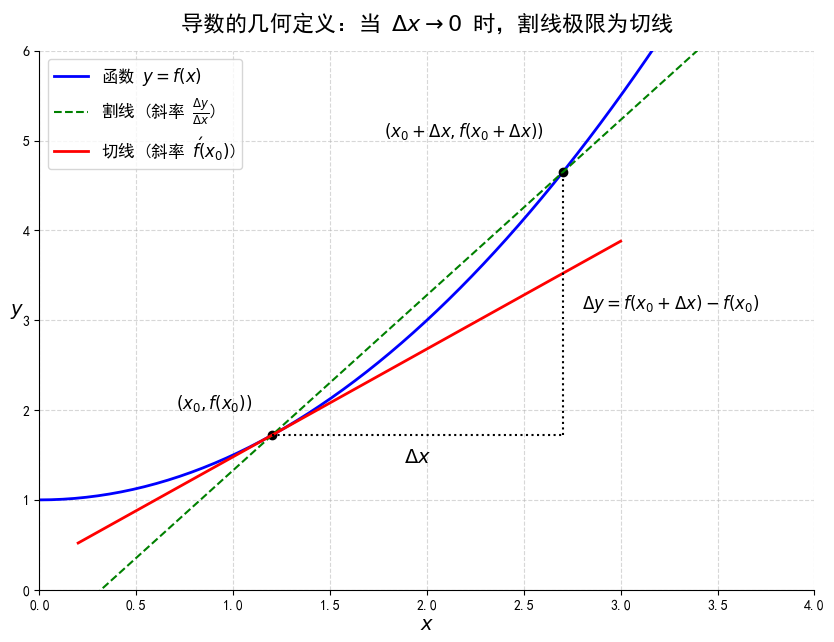

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 设置支持中文的字体（如果你的环境中没有SimHei，可以替换为其他中文字体或纯英文）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 定义一个示例函数 f(x) = 0.5 * x^2 + 1 及其导数 f'(x) = x
def f(x):
    return 0.5 * x**2 + 1

def df(x):
    return x

# 生成 X 轴的数据点
x = np.linspace(0, 4, 200)
y = f(x)

# 设定 x0 和 增量 dx
x0 = 1.2
dx = 1.5
x1 = x0 + dx

# 计算对应的 y 值
y0 = f(x0)
y1 = f(x1)

# 创建画布
fig, ax = plt.subplots(figsize=(10, 7))

# 1. 绘制函数曲线
ax.plot(x, y, 'b-', linewidth=2, label=r'函数 $y=f(x)$')

# 2. 绘制 x0 和 x0+dx 两个点
ax.plot([x0, x1], [y0, y1], 'ko', markersize=6)

# 3. 绘制割线 (Secant line)
m_secant = (y1 - y0) / dx
x_sec = np.linspace(0.2, 3.8, 100)
y_sec = y0 + m_secant * (x_sec - x0)
ax.plot(x_sec, y_sec, 'g--', linewidth=1.5, label=r'割线 (斜率 $\frac{\Delta y}{\Delta x}$)')

# 4. 绘制 x0 处的切线 (Tangent line)
m_tangent = df(x0)
x_tan = np.linspace(0.2, 3.0, 100)
y_tan = y0 + m_tangent * (x_tan - x0)
ax.plot(x_tan, y_tan, 'r-', linewidth=2, label=r'切线 (斜率 $f\'(x_0)$)')

# 5. 标注辅助线和增量 (Delta x 和 Delta y)
ax.plot([x0, x1], [y0, y0], 'k:', linewidth=1.5) # 水平辅助线
ax.plot([x1, x1], [y0, y1], 'k:', linewidth=1.5) # 垂直辅助线

# 添加文本标注
ax.text(x0 + dx/2, y0 - 0.3, r'$\Delta x$', fontsize=14, color='black', ha='center')
ax.text(x1 + 0.1, (y0 + y1)/2, r'$\Delta y = f(x_0+\Delta x)-f(x_0)$', fontsize=12, color='black', va='center')

ax.text(x0 - 0.1, y0 + 0.3, r'$(x_0, f(x_0))$', fontsize=12, ha='right')
ax.text(x1 - 0.1, y1 + 0.4, r'$(x_0+\Delta x, f(x_0+\Delta x))$', fontsize=12, ha='right')

# 坐标轴设置
ax.set_xlim(0, 4)
ax.set_ylim(0, 6)
ax.set_xlabel(r'$x$', fontsize=14)
ax.set_ylabel(r'$y$', fontsize=14, rotation=0)
ax.set_title(r'导数的几何定义：当 $\Delta x \to 0$ 时，割线极限为切线', fontsize=16, pad=15)

# 隐藏顶部和右侧的边框，使图表更像数学坐标系
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# 显示图例和网格
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

# 展示图像
plt.show()

## 微分的几何意义

为了对微分有比较直观的了解,我们来说明微分的几何意义。

在直角坐标系中,函数$y=f(x)$的图形是一条曲线。  
对于某一固定的$x_0$值，曲线上有一个确定点$M(x_0,y_0)$，当自变量$x$有微小增量$\Delta x$时，就得到曲线上另一点 $N(x+\Delta x,y+ \Delta Ay)$。

从图 2-11 可知:

$$
\begin{align}
MQ = \Delta x   \\
QN = \Delta y
\end{align}
$$

过点$M$作曲线的切线$MT$,它的倾角为 $\alpha$
则
$$
OP=MQ·tan \alpha =\Delta x · f'(x_0)
$$
即
$$
dy=QP
$$

&emsp;&emsp;由此可见，对于可微函数$y=f(x)$而言，  
当$\Delta y$是曲线$y=f(x)$上的点的纵坐标的增量时，  $dy$就是曲线的切线上点的纵坐标的相应增量。


&emsp;&emsp;当$|\Delta x|$很小时，$|\Delta y-dy|$比$|\Delta x|$小得多，因此在点$M$的邻近，我们可以用**切线段**来近似代替**曲线段**。在局部范围内用**线性函数**近似代替**非线性函数**，在几何上就是局部用**切线段**近似代替**曲线段**，  
&emsp;&emsp;这在数学上称为**非线性函数的局部线性化**，这是微分学的基本思想方法之一。这种思想方法在自然科学和工程问题的研究中是经常采用的。

In [4]:
from IPython.display import IFrame

# 使用相对路径或绝对路径
IFrame('assets/DerivativesAndDifferentials.html', width=1000, height=800)


## 一元函数的梯度

$
\begin{align}
y' & = 2x \\  
y' & = 0 时，x=0, y=0
\end{align}
$

2.0
1.2000000000000002
0.4


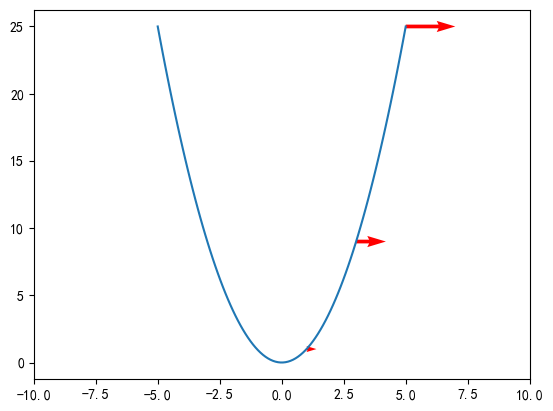

In [6]:
import numpy as np
import matplotlib.pyplot as plt

ax = plt.gca()
ax.set_xlim(-10,10)
x = np.linspace(-5, 5, 100)
y = x**2

# 原函数
def f(x):
    return x**2

# 导函数
def fdx(x):
    return 2*x

eta = 0.2
# (x0)
x0 = 5
fdx0 = fdx(x0) *eta
print(fdx0)
ax.quiver(x0, f(x0), fdx0, 0, color="r", angles='xy', scale_units='xy', scale=1)
x1 = 3
fdx1 = fdx(x1) *eta
print(fdx1)
ax.quiver(x1, f(x1), fdx1, 0, color="r", angles='xy', scale_units='xy', scale=1)
x2 = 1
fdx2 = fdx(x2) *eta
print(fdx2)
ax.quiver(x2, f(x2), fdx2, 0, color="r", angles='xy', scale_units='xy', scale=1)
plt.plot(x,y)

计算$y=x^2$的最小值

通过梯度下降法计算函数的最小值

3.0
1.7999999999999998
1.0799999999999998
0.6479999999999999
0.3887999999999999
0.23327999999999993
0.13996799999999995
0.08398079999999997
0.05038847999999998
0.030233087999999984
0.018139852799999988
0.010883911679999993
0.006530347007999996
0.0039182082047999976
0.0023509249228799984
0.001410554953727999
0.0008463329722367994
0.0005077997833420796
0.0003046798700052478
0.00018280792200314866
极小值 3.341873634710928e-08


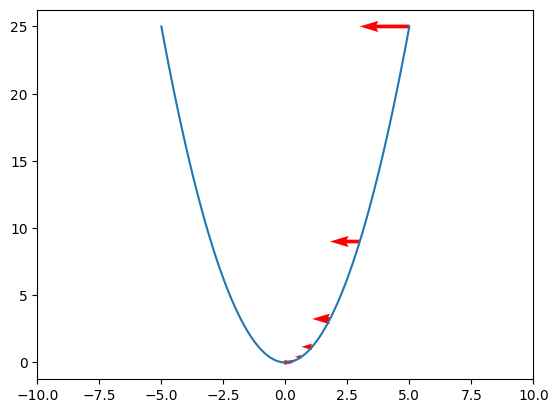

In [13]:
import numpy as np
import matplotlib.pyplot as plt

ax = plt.gca()
ax.set_xlim(-10, 10)
x = np.linspace(-5, 5, 100)
y = x**2

# 原函数
def f(x):
    return x**2

# 导函数
def fdx(x):
    return 2*x
    
# (x0)
x_current = 5

# 偏导数 (x_0)

#梯度向量

# 学习率 0.1
eta = 0.2
theta = 0.001

# 记录下初始x y值
x_history = [x_current]

cnt = 0
while True:
    fx_current = fdx(x_current) 
    ax.quiver(x_current, f(x_current), -eta*fx_current, 0, color="r", angles='xy', scale_units='xy', scale=1)
    x_current = x_current - eta * fx_current
    x_history.append(x_current)
    print(x_current)
    cnt+=1
    if fx_current < theta:
        break
print("极小值", f(x_history[-1]))
plt.plot(x,y)